<a href="https://colab.research.google.com/github/Hellokrrish/Machine-Learning/blob/main/K_means_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [14]:
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=1)

In [15]:
x

array([[-3.05837272,  4.48825769],
       [-8.60973869, -3.72714879],
       [ 1.37129721,  5.23107449],
       ...,
       [-1.91854276,  4.59578307],
       [-1.79600465,  4.28743568],
       [-6.97684609, -8.89498834]])

In [16]:
y # In unsupervised learning we will not use y.

array([0, 1, 0, 1, 2, 2, 2, 2, 0, 1, 2, 2, 0, 0, 0, 2, 1, 0, 2, 2, 1, 1,
       2, 0, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 2, 1, 0, 1, 2,
       2, 1, 2, 0, 2, 1, 0, 2, 1, 2, 0, 2, 2, 1, 1, 0, 1, 2, 2, 2, 1, 0,
       0, 0, 0, 2, 2, 1, 2, 2, 1, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 1,
       0, 2, 1, 0, 2, 0, 2, 2, 0, 1, 2, 2, 2, 1, 0, 2, 1, 2, 1, 2, 2, 0,
       1, 2, 1, 0, 1, 1, 0, 1, 2, 2, 2, 0, 1, 2, 2, 2, 0, 1, 0, 0, 0, 2,
       0, 1, 1, 2, 2, 2, 1, 2, 0, 0, 2, 2, 1, 0, 2, 2, 2, 1, 2, 0, 1, 0,
       1, 2, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       2, 1, 2, 1, 1, 0, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 1, 2, 1, 0, 0, 2,
       0, 2, 2, 1, 1, 2, 2, 1, 1, 0, 1, 0, 2, 0, 1, 1, 1, 2, 0, 0, 1, 0,
       0, 2, 1, 2, 0, 1, 0, 2, 2, 1, 2, 0, 2, 0, 0, 2, 0, 1, 1, 0, 0, 1,
       2, 0, 0, 1, 2, 0, 2, 0, 1, 1, 0, 0, 2, 1, 1, 0, 0, 1, 0, 2, 1, 2,
       2, 2, 2, 2, 1, 2, 0, 1, 0, 2, 2, 0, 0, 2, 1, 2, 0, 1, 0, 0, 2, 2,
       0, 1, 1, 2, 2, 0, 0, 2, 1, 0, 1, 1, 2, 0, 1,

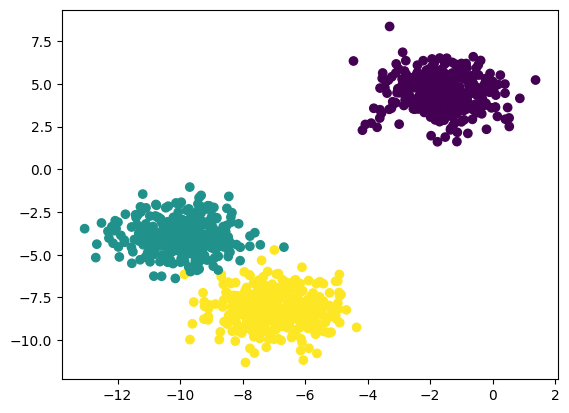

In [17]:
plt.scatter(x[:,0],x[:,1],c=y)

In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

In [19]:
x_train.shape,x_test.shape

((700, 2), (300, 2))

In [20]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3)

In [21]:
kmeans

KMeans(n_clusters=3)

In [22]:
kmeans.fit(x_train)

KMeans(n_clusters=3)

In [23]:
y_labels=kmeans.predict(x_train)

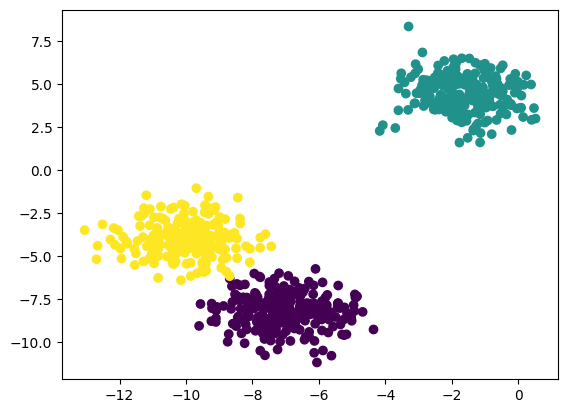

In [26]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_labels)

In [27]:
# how to better the clustering model
from sklearn.metrics import silhouette_score
silhouette_score(x_train,kmeans.labels_)

0.7179451230427786

In [28]:
kmeans.inertia_# for n=3 we have wcss distance

1405.68005178494

In [29]:
# how to select k(centroid) we have elbow method.
wcss=[]
for k in range(1,10):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [30]:
wcss

[29004.511743610456,
 4501.242392684225,
 1405.68005178494,
 1239.1395569738304,
 1105.5209226240456,
 911.3446114325137,
 805.6562999858281,
 712.2262763407894,
 616.4114764284217]

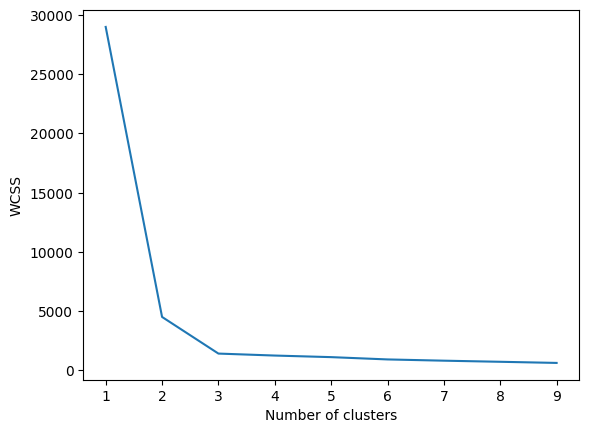

In [31]:
# make a plot for elbow:
plt.plot(range(1,10),wcss)
plt.xticks(range(1,10))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [32]:
pip install kneed

In [34]:
from kneed import KneeLocator
k1=KneeLocator(range(1,10),wcss,curve='convex',direction='decreasing')
k1

In [35]:
k1.elbow

2

In [37]:
silhouette_coeff=[]
for k in range(2,10):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coeff.append(score)

In [38]:
silhouette_coeff

[0.7674998364431159,
 0.7179451230427786,
 0.5676019865209324,
 0.5901829629812588,
 0.41689307544420945,
 0.3217934183974426,
 0.3321936902271013,
 0.3480440270706121]